In [48]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
data = pd.read_csv("/content/sample_data/final_patent_dataset_balanced.csv")

data.head()

,clean_text,novelty tier
0,power generation unit oceanographic sensor moo...,0
1,novel container design built overrun meter pre...,2
2,system rapid bake semiconductor substrate uppe...,2
3,electromechanical brake booster disclosed elec...,1
4,time pressure dosing fuel additive delivery sy...,1


In [51]:
X = data["clean_text"]
y = data["novelty tier"]

In [41]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(X)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [44]:
y_pred = model.predict(X_test)

In [45]:
f1 = f1_score(y_test, y_pred, average="macro")

print("Macro F1 Score:", f1)

Macro F1 Score: 0.6547067786719325


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.55      0.56       240
           1       0.52      0.49      0.51       236
           2       0.67      0.69      0.68       264
           3       0.85      0.90      0.87       260

    accuracy                           0.66      1000
   macro avg       0.65      0.66      0.65      1000
weighted avg       0.66      0.66      0.66      1000



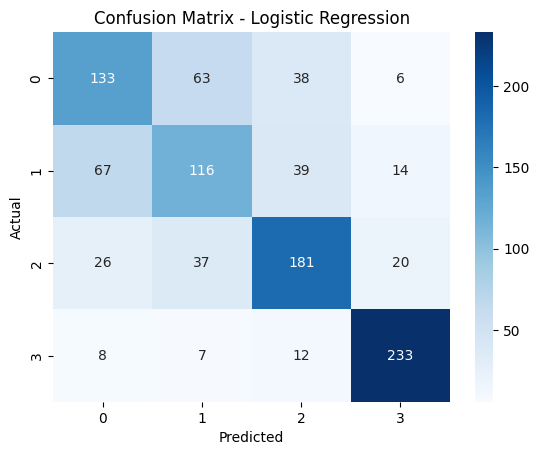

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()